<a href="https://colab.research.google.com/github/hananlu/aiBigData/blob/master/Week_10_Decision_Tree_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

jumlah_data = 1000

usia_pakai = np.random.randint(
    1,
    6,
    jumlah_data
)

ram = np.random.choice(
    [4, 8, 16, 32],
    jumlah_data
)

ssd = np.random.choice(
    [128, 256, 512, 1024],
    jumlah_data
)

baterai = np.random.randint(
    60,
    101,
    jumlah_data
)

harga = (
    15000
    - (usia_pakai * 1500)
    + (ram * 500)
    + (ssd * 5)
    + (baterai * 50)
    + np.random.normal(0, 1000, jumlah_data)
)

In [ ]:
df = pd.DataFrame({
    "usia_pakai": usia_pakai,
    "ram": ram,
    "ssd": ssd,
    "baterai": baterai,
    "harga":harga
})

df.head()

,usia_pakai,ram,ssd,baterai,harga
0,4,32,512,60,28995.086631
1,5,32,1024,83,32552.806650
2,3,32,128,94,30755.466207
3,5,32,1024,83,31753.750826
4,5,32,512,76,28852.816306


In [ ]:
print(f"Jumlah Baris {df.shape[0]}")
print(f"Jumlah Kolom {df.shape[1]}")

Jumlah Baris 1000
Jumlah Kolom 5


In [ ]:
print(f"Harga Rata-rata {df["harga"].mean()}")

Harga Rata-rata 24180.47283688914


In [ ]:
df[df["harga"] > df["harga"].mean()]

,usia_pakai,ram,ssd,baterai,harga
0,4,32,512,60,28995.086631
1,5,32,1024,83,32552.806650
2,3,32,128,94,30755.466207
3,5,32,1024,83,31753.750826
4,5,32,512,76,28852.816306
...,...,...,...,...,...
986,5,32,1024,78,32600.706626
989,2,16,128,90,24849.289257
990,2,8,1024,76,25617.065274
995,2,8,1024,95,24788.862887


In [ ]:
hargaLebihRata = df[df["harga"] > df["harga"].mean()].shape[0]


In [ ]:
hargaLebihRata

422

In [ ]:
df.head()

,usia_pakai,ram,ssd,baterai,harga
0,4,32,512,60,28995.086631
1,5,32,1024,83,32552.806650
2,3,32,128,94,30755.466207
3,5,32,1024,83,31753.750826
4,5,32,512,76,28852.816306


In [ ]:
df.isnull().sum()

,0
usia_pakai,0
ram,0
ssd,0
baterai,0
harga,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
X = df.drop(columns="harga")
y = df["harga"]

In [ ]:
X

,usia_pakai,ram,ssd,baterai
0,4,32,512,60
1,5,32,1024,83
2,3,32,128,94
3,5,32,1024,83
4,5,32,512,76
...,...,...,...,...
995,2,8,1024,95
996,1,8,128,67
997,1,16,1024,79
998,4,8,128,91


In [ ]:
y

,harga
0,28995.086631
1,32552.806650
2,30755.466207
3,31753.750826
4,28852.816306
...,...
995,24788.862887
996,22240.536115
997,31268.220836
998,17320.019808


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(800, 4)

In [ ]:
X_test.shape

(200, 4)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 2098902.7289928994
Root Mean Squared Error: 1448.759030685538
R-squared: 0.9426710664948855


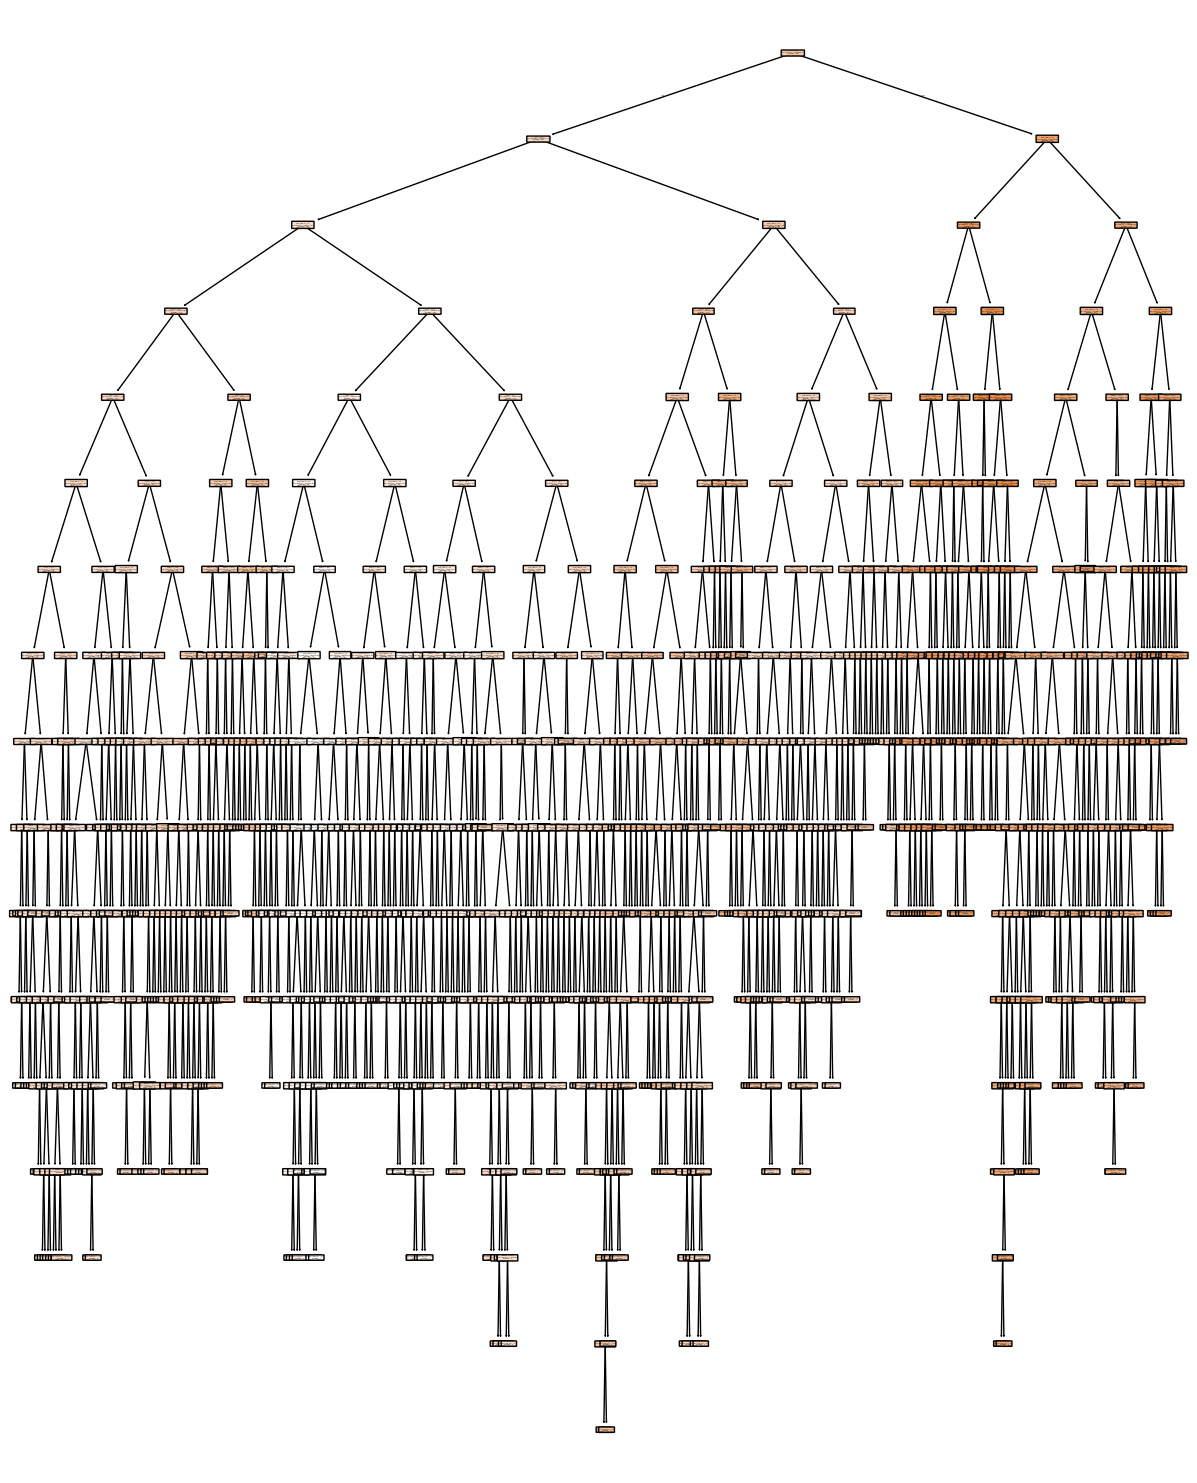

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 19))

plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.show()

In [ ]:
X = df.drop(columns="harga")
y = df["harga"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
y_pred_depth = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred_depth)
rmse = root_mean_squared_error(y_test, y_pred_depth)
r2 = r2_score(y_test, y_pred_depth)

In [ ]:
print(f"Mean Square Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R-squared : {r2}")

Mean Square Error : 5088471.076597507
Root Mean Square Error : 2255.7639673949725
R-squared : 0.8610147026046657


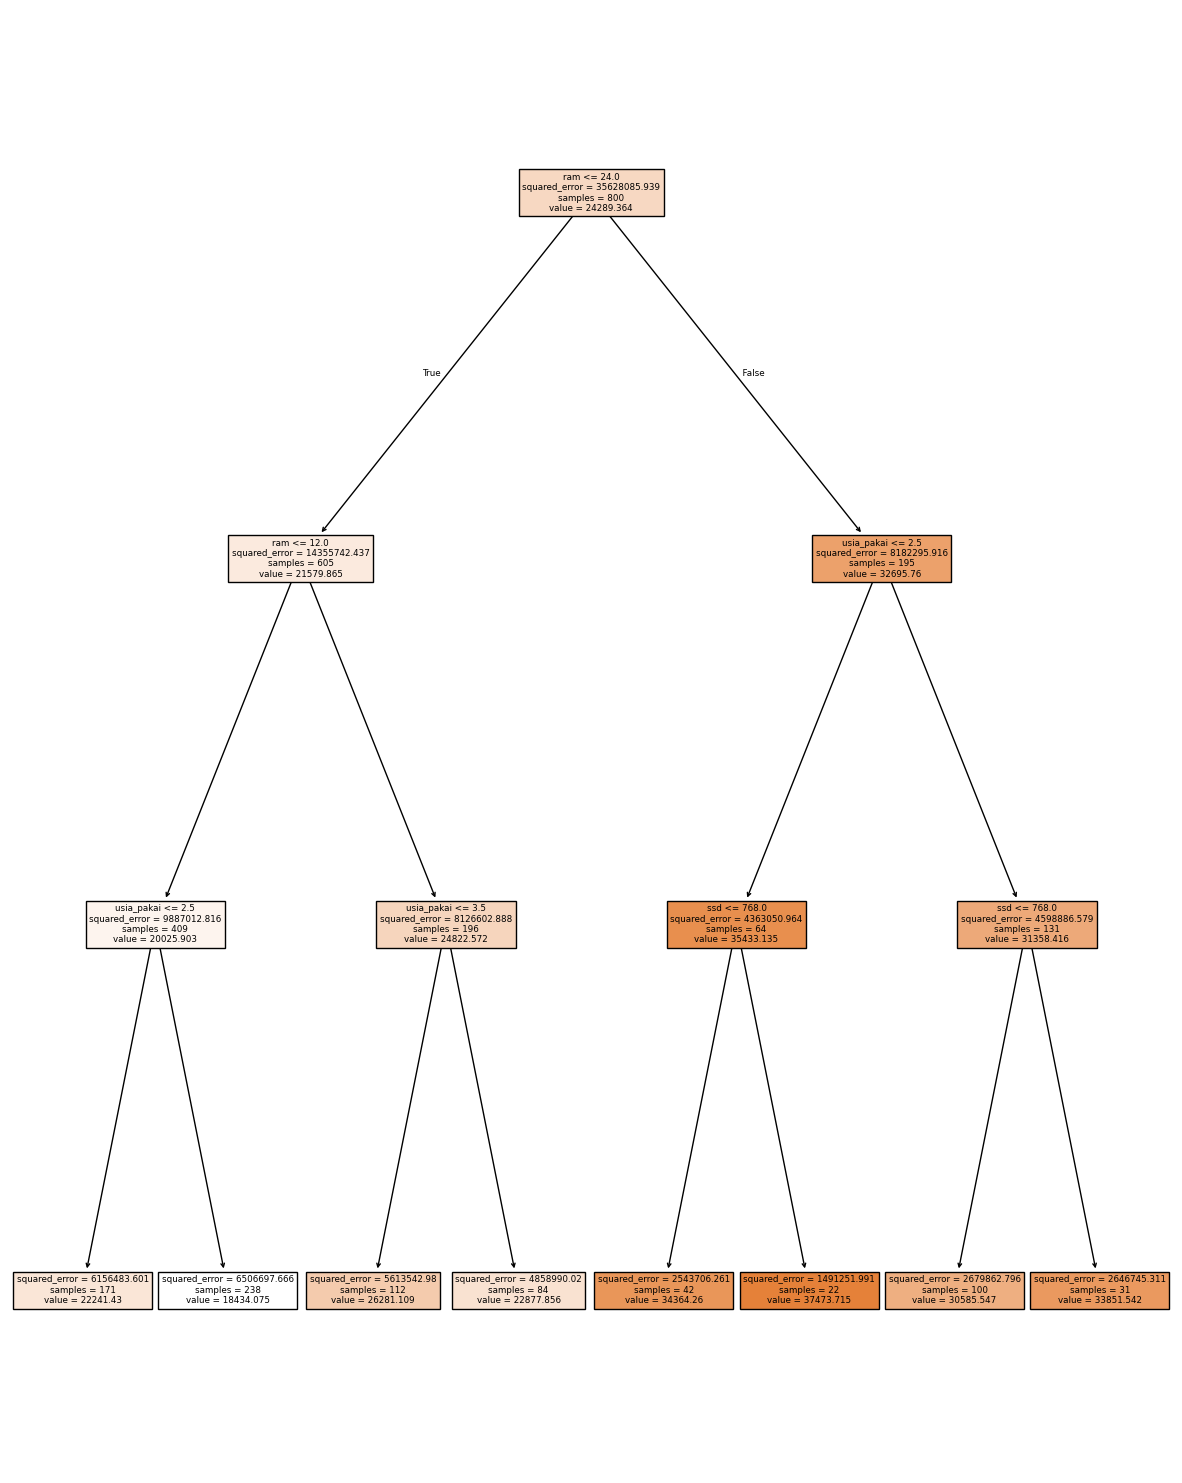

In [ ]:
plt.figure(figsize=(15, 19))

plot_tree(model, feature_names=X.columns, filled=True)

plt.show()

In [ ]:
X = df.drop(columns="harga")
y = df["harga"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = DecisionTreeRegressor(max_depth=3, random_state=42, max_leaf_nodes=4)
model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=3, max_leaf_nodes=4, random_state=42)

In [ ]:
y_pred_scaled = model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred_scaled)
rmse = root_mean_squared_error(y_test, y_pred_scaled)
r2 = r2_score(y_test, y_pred_scaled)

In [ ]:
print(f"Mean Square Error : {mse}")
print(f"Root Mean Square Error : {rmse}")
print(f"R-squared : {r2}")

Mean Square Error : 7972789.9956348445
Root Mean Square Error : 2823.612933040725
R-squared : 0.7822330967527471


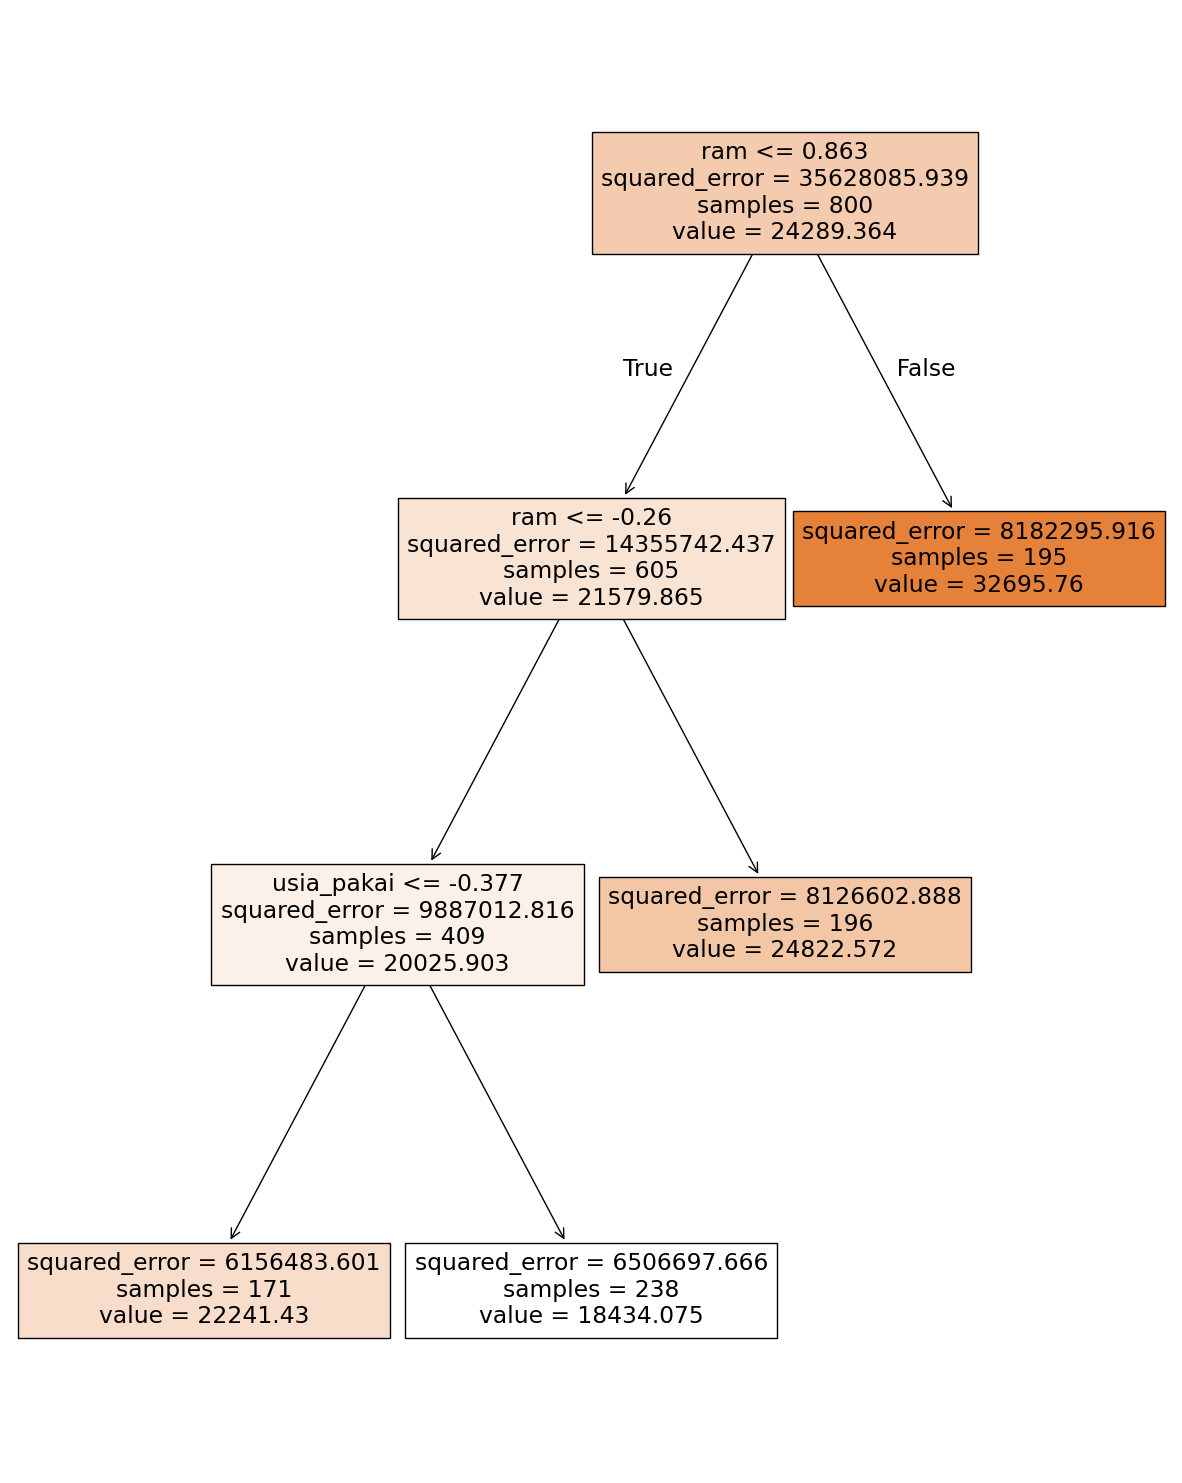

In [ ]:
plt.figure(figsize=(15, 19))

plot_tree(model, feature_names=X.columns, filled=True)

plt.show()